In [1]:

# Deneyi farklı kategoriler için tekrarlamak istediğimizde sadece burayı değiştireceğiz.
CATEGORY =   "bottle"           # categories = "carpet" , "hazelnut" , "bottle"
# -----------------
print(f"Selected Category:{CATEGORY}")

Selected Category:bottle


In [2]:
import torch
import torchvision.models as models
from google.colab import drive
import os
import time




drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/anomaly_detection_project/dataset/'

PROJECT_DIR = f'/content/drive/MyDrive/anomaly_detection_project/padim_manual_{CATEGORY}/'
os.makedirs(PROJECT_DIR, exist_ok=True)
print(f"'{CATEGORY}' kategorisi için çalışılacak. Proje yolu: {PROJECT_DIR}")

model = models.wide_resnet50_2(weights=models.Wide_ResNet50_2_Weights.DEFAULT)
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"Model '{device}' cihazına taşındı")

features = {}
def get_features_hook(name):
    def hook(model, input, output):
        features[name] = output.detach()
    return hook

model.layer2.register_forward_hook(get_features_hook('layer2'))
model.layer3.register_forward_hook(get_features_hook('layer3'))

Mounted at /content/drive
'bottle' kategorisi için çalışılacak. Proje yolu: /content/drive/MyDrive/anomaly_detection_project/padim_manual_bottle/


Downloading: "https://download.pytorch.org/models/wide_resnet50_2-9ba9bcbe.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-9ba9bcbe.pth
100%|██████████| 263M/263M [00:01<00:00, 204MB/s]


Model 'cuda' cihazına taşındı


In [3]:

start_time = time.time()
print("\nTimer started. All subsequent computation time will be measured.")


Timer started. All subsequent computation time will be measured.


In [4]:
from PIL import Image
import glob
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


class MVTecDataset(Dataset):
    def __init__(self, root_dir, category):
        self.root_dir = root_dir
        self.category = category
        self.image_paths = []

        self.transform = transforms.Compose([
            transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        self._setup_paths()

    def _setup_paths(self):
        class_dir = os.path.join(self.root_dir, self.category, 'train', 'good')
        self.image_paths = sorted(glob.glob(os.path.join(class_dir, '*.png')))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        image_tensor = self.transform(image)
        return image_tensor

train_dataset = MVTecDataset(root_dir=BASE_DIR, category=CATEGORY)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"\nEğitim veri yükleyici '{CATEGORY}' kategorisi için oluşturuldu.")
print(f"İçerdiği normal görsel sayısı: {len(train_dataset)}")


Eğitim veri yükleyici 'bottle' kategorisi için oluşturuldu.
İçerdiği normal görsel sayısı: 209


In [5]:
from tqdm import tqdm
import torch.nn.functional as F
import torch


embedding_vectors = []
with torch.no_grad():
    for batch in tqdm(train_dataloader, desc=f"'{CATEGORY}' için özellikler çıkarılıyor"):

        images = batch.to(device)

        model(images)

        layer2_features = features['layer2']
        layer3_features = features['layer3']

        layer2_features_resized = F.interpolate(
            layer2_features,
            size=layer3_features.shape[2:],
            mode='bilinear',
            align_corners=False
        )
        combined_features = torch.cat((layer2_features_resized, layer3_features), dim=1)

        embedding_vectors.append(combined_features)

embedding_vectors_tensor = torch.cat(embedding_vectors, dim=0)

embedding_vectors_tensor = embedding_vectors_tensor.cpu()

print(f"Biriktirilen özelliklerin boyutu (Resim Sayısı, Kanal Sayısı, Yükseklik, Genişlik): {embedding_vectors_tensor.shape}")

'bottle' için özellikler çıkarılıyor: 100%|██████████| 7/7 [01:02<00:00,  8.90s/it]


Biriktirilen özelliklerin boyutu (Resim Sayısı, Kanal Sayısı, Yükseklik, Genişlik): torch.Size([209, 1536, 16, 16])


In [7]:
from tqdm import tqdm
import torch


N, C, H, W = embedding_vectors_tensor.shape
embedding_reshaped = embedding_vectors_tensor.view(N, C, H * W).permute(2, 0, 1)

means = []
covs_inv = []

epsilon = 1e-4
identity = torch.eye(C)

for i in tqdm(range(embedding_reshaped.shape[0]), desc="İstatistiksel model oluşturuluyor"):

    patch_features_at_loc_i = embedding_reshaped[i, :, :]


    mean = torch.mean(patch_features_at_loc_i, dim=0)
    cov = torch.cov(patch_features_at_loc_i.T)

    cov_inv = torch.linalg.inv(cov + epsilon * identity)

    means.append(mean)
    covs_inv.append(cov_inv)

padim_means = torch.stack(means)
padim_covs_inv = torch.stack(covs_inv)

print(f"Ortalama vektörlerinin boyutu: {padim_means.shape}")
print(f"Ters kovaryans matrislerinin boyutu: {padim_covs_inv.shape}")

İstatistiksel model oluşturuluyor: 100%|██████████| 256/256 [00:08<00:00, 28.91it/s]


Ortalama vektörlerinin boyutu: torch.Size([256, 1536])
Ters kovaryans matrislerinin boyutu: torch.Size([256, 1536, 1536])


In [8]:
from PIL import Image
import glob
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


class MVTecDataset(Dataset):
    def __init__(self, root_dir, category, split='train'):
        self.root_dir = root_dir
        self.category = category
        self.split = split
        self.image_paths = []
        self.labels = []

        self.transform = transforms.Compose([
            transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        self._setup_paths()

    def _setup_paths(self):
        if self.split == 'train':
            class_dir = os.path.join(self.root_dir, self.category, 'train', 'good')
            self.image_paths = sorted(glob.glob(os.path.join(class_dir, '*.png')))
            self.labels = [0] * len(self.image_paths)
        else: # test
            test_dir = os.path.join(self.root_dir, self.category, 'test')
            class_dirs = sorted([f for f in glob.glob(os.path.join(test_dir, '*')) if os.path.isdir(f)])
            for class_dir in class_dirs:
                class_name = os.path.basename(class_dir)
                paths = sorted(glob.glob(os.path.join(class_dir, '*.png')))
                self.image_paths.extend(paths)
                self.labels.extend([0 if class_name == 'good' else 1] * len(paths)) # 0: Normal, 1: Anomali

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(image_path).convert("RGB")
        image_tensor = self.transform(image)
        return {"image": image_tensor, "label": label}

test_dataset = MVTecDataset(root_dir=BASE_DIR, category=CATEGORY, split='test')
test_dataloader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2)

print(f"\nTest veri yükleyici '{CATEGORY}' kategorisi için oluşturuldu.")
print(f"İçerdiği normal ve anormal görsel sayısı: {len(test_dataset)}")


Test veri yükleyici 'bottle' kategorisi için oluşturuldu.
İçerdiği normal ve anormal görsel sayısı: 83


In [9]:
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import torch.nn.functional as F
import torch
import numpy as np

test_image_scores = []
test_labels = []

padim_means = padim_means.to(device)
padim_covs_inv = padim_covs_inv.to(device)

with torch.no_grad():
    for batch in tqdm(test_dataloader, desc=f"Testing on '{CATEGORY}'"):

        images = batch["image"].to(device)
        labels = batch["label"]

        model(images)
        layer2_features = features['layer2']
        layer3_features = features['layer3']
        layer2_features_resized = F.interpolate(layer2_features, size=layer3_features.shape[2:], mode='bilinear', align_corners=False)
        test_embeddings = torch.cat((layer2_features_resized, layer3_features), dim=1)

        test_embeddings_reshaped = test_embeddings.permute(0, 2, 3, 1).reshape(test_embeddings.shape[0], -1, test_embeddings.shape[1])

        diff = test_embeddings_reshaped - padim_means
        left_term = torch.matmul(diff.unsqueeze(-2), padim_covs_inv)
        distances_sq = torch.matmul(left_term, diff.unsqueeze(-1)).squeeze()
        distances = torch.sqrt(distances_sq.clamp(min=0))

        _, _, H, W = layer3_features.shape
        anomaly_map = distances.reshape(-1, H, W)
        image_scores = torch.max(anomaly_map.view(len(images), -1), dim=1).values

        test_image_scores.append(image_scores.cpu())
        test_labels.append(labels.cpu())

all_scores = torch.cat(test_image_scores).numpy()
all_labels = torch.cat(test_labels).numpy()

auroc_score = roc_auc_score(all_labels, all_scores)


print(f"Calculated AUROC Score for Manual PaDiM ({CATEGORY.capitalize()}): {auroc_score:.4f}")

Testing on 'bottle': 100%|██████████| 11/11 [00:34<00:00,  3.10s/it]

Calculated AUROC Score for Manual PaDiM (Bottle): 1.0000


Best Threshold found: 1640.2484

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        20
     Anomaly       1.00      1.00      1.00        63

    accuracy                           1.00        83
   macro avg       1.00      1.00      1.00        83
weighted avg       1.00      1.00      1.00        83


Confusion Matrix:


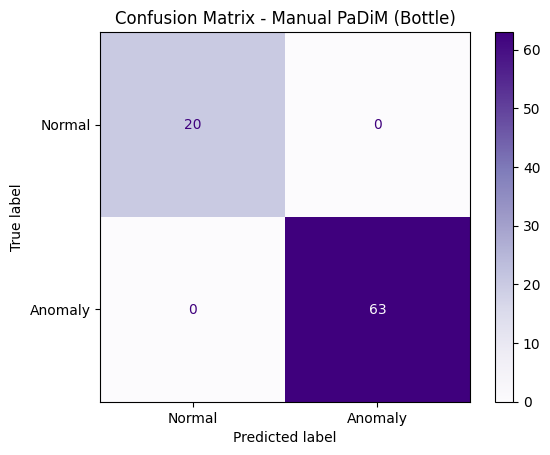


ROC Curve:


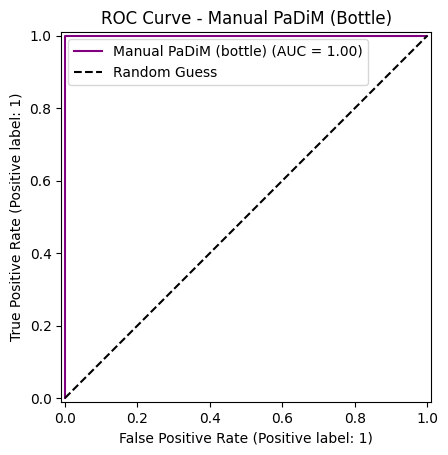

In [10]:
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay, classification_report, RocCurveDisplay
import numpy as np
import matplotlib.pyplot as plt


fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
J = tpr - fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]
y_pred = (all_scores >= best_thresh).astype(int)

print(f"Best Threshold found: {best_thresh:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, y_pred, target_names=['Normal', 'Anomaly']))

print("\nConfusion Matrix:")
ConfusionMatrixDisplay.from_predictions(all_labels, y_pred, display_labels=['Normal', 'Anomaly'], cmap=plt.cm.Purples)
plt.title(f"Confusion Matrix - Manual PaDiM ({CATEGORY.capitalize()})")
plt.show()

print("\nROC Curve:")
RocCurveDisplay.from_predictions(
    all_labels,
    all_scores,
    name=f"Manual PaDiM ({CATEGORY})",
    color="purple"
)
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title(f"ROC Curve - Manual PaDiM ({CATEGORY.capitalize()})")
plt.legend()
plt.show()

In [11]:

end_time = time.time()
elapsed_time = end_time - start_time

print(f"The process took {elapsed_time:.2f} seconds.")
print(f"({elapsed_time / 60:.2f} minutes)")

The process took 137.98 seconds.
(2.30 minutes)
